**Preprocessing and obtaining the rr intervals**

Loading data

In [2]:
import pandas as pd
import wfdb
import os

# 1. SET YOUR LOCAL PATH
folder_path = r'C:\Users\34673\Desktop\UNI\UNI 2025\TFG\datasest_cardio\dataset_cardio' 

# 2. LOAD THE CSV
# This combines the folder above with the specific filename 'subject-info.csv'
csv_path = os.path.join(folder_path, 'subject-info.csv')
subject_info = pd.read_csv(csv_path)

# Convert the ID column to match your filenames (e.g., 1 -> '0001')
subject_info['ID_str'] = subject_info['ID'].astype(str).str.zfill(4)
subject_info.set_index('ID_str', inplace=True)

# 3. LOAD RECORDS AND BIND INFO
patients = {}

for i in range(1, 1122):
    pid = str(i).zfill(4)
    record_path = os.path.join(folder_path, pid)
    
    if os.path.exists(record_path + '.hea'):
        try:
            # Load the signals (ECG1, ECG2, NIBP)
            record = wfdb.rdrecord(record_path)
            
            # Link CSV data to the record object
            if pid in subject_info.index:
                # Store the CSV row as a dictionary inside the record
                record.metadata = subject_info.loc[pid].to_dict()
            else:
                record.metadata = None
                
            patients[pid] = record
            
        except Exception as e:
            print(f"Error loading {pid}: {e}")

print(f"Total patients with signals and metadata: {len(patients)}")

Error loading 0400: [Errno 2] No such file or directory: 'C:/Users/34673/Desktop/UNI/UNI 2025/TFG/datasest_cardio/dataset_cardio/0400.dat'
Total patients with signals and metadata: 1120


In [3]:
# Choose a patient ID
pid = '0001'

if pid in patients:
    # Access the record and its bound metadata
    p_record = patients[pid]
    p_info = p_record.metadata
    
    print(f"--- Information for Patient {pid} ---")
    print(f"Age Group: {p_info['Age_group']}")
    print(f"Sex: {'Male' if p_info['Sex'] == 0.0 else 'Female'}")
    print(f"BMI: {p_info['BMI']}")
    print(f"Record Length: {p_info['Length']} minutes")
    print(f"Device ID: {p_info['Device']}")
    print(f"Signals Available: {p_record.sig_name}")
else:
    print(f"Patient {pid} not found.")

--- Information for Patient 0001 ---
Age Group: 2.0
Sex: Female
BMI: 23.0
Record Length: 15.0 minutes
Device ID: 0.0
Signals Available: ['ECG1', 'ECG2', 'NIBP']


**1. Visualization of Data**

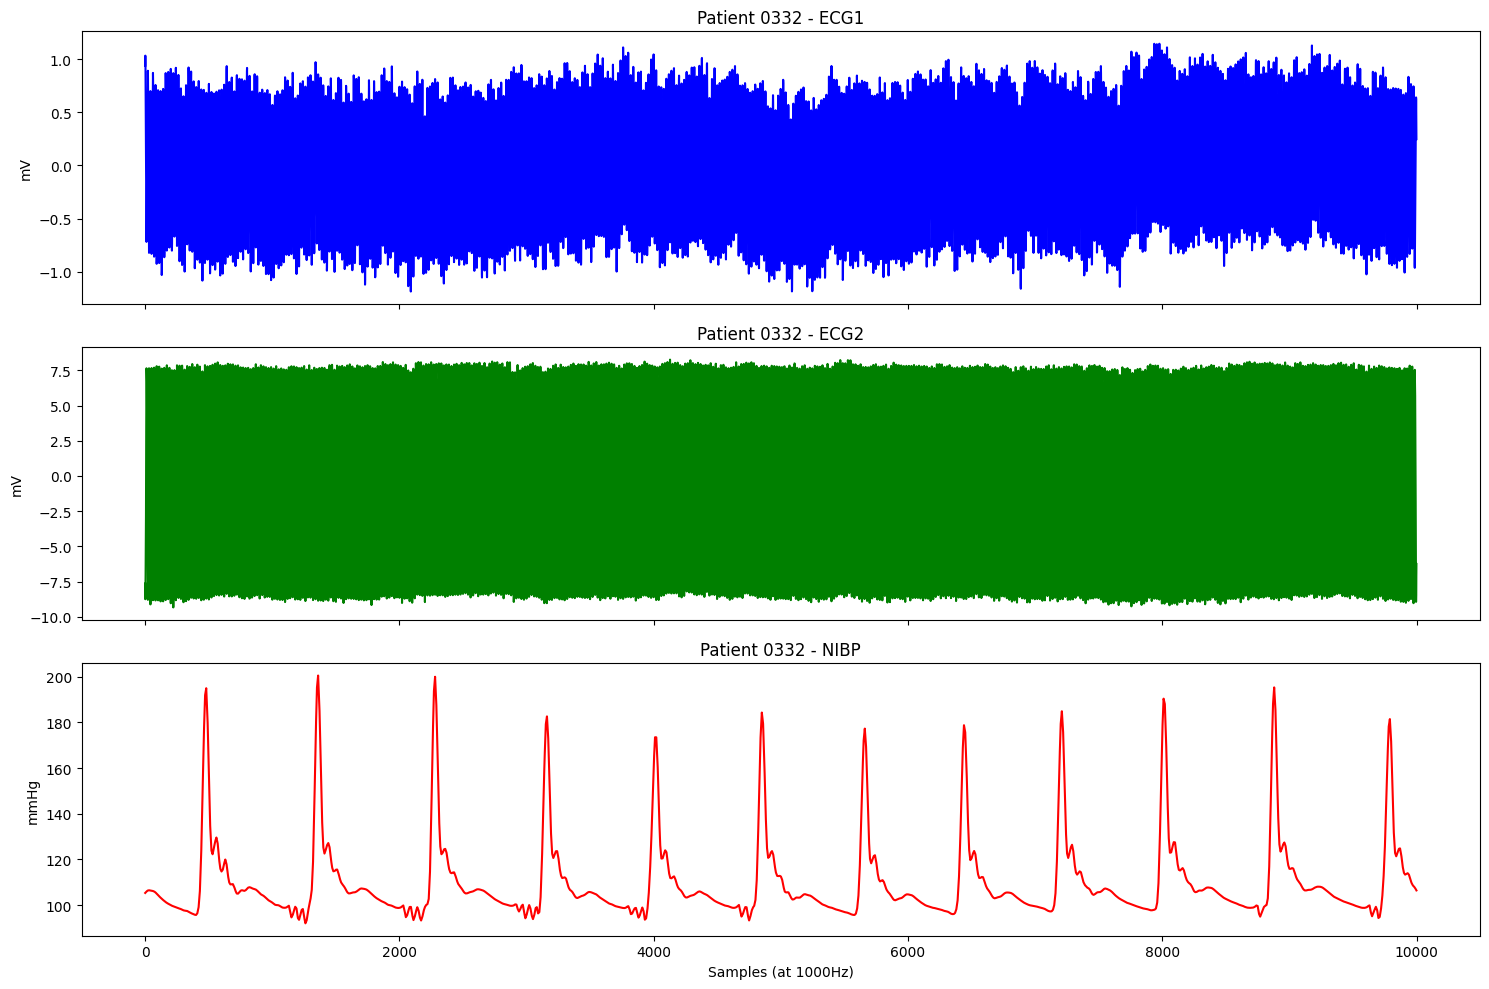

In [4]:
import matplotlib.pyplot as plt

# Select the patient ID, in this case doing patient 1
pid = '0332'

# Create a figure with 3 subplots (one for each signal)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

# 1. Plot ECG1
ax1.plot(patients[pid].p_signal[:10000, 0], color='blue')
ax1.set_title(f"Patient {pid} - {patients[pid].sig_name[0]}")
ax1.set_ylabel('mV')

# 2. Plot ECG2
ax2.plot(patients[pid].p_signal[:10000, 1], color='green')
ax2.set_title(f"Patient {pid} - {patients[pid].sig_name[1]}")
ax2.set_ylabel('mV')

# 3. Plot NIBP (Non-Invasive Blood Pressure)
ax3.plot(patients[pid].p_signal[:10000, 2], color='red')
ax3.set_title(f"Patient {pid} - {patients[pid].sig_name[2]}")
ax3.set_ylabel('mmHg')

plt.xlabel("Samples (at 1000Hz)")
plt.tight_layout()
plt.show()

**2. Preprocessing**

ECG 5 min and bandpass (https://github.com/obarquero/PyCardio/blob/master/HRV/under_development/read_data_hrv_anal.py) (https://github.com/KChen89/QRS-detection/blob/master/QRS.pyand) and denoising. Simplified version for pan tompkins for R peak detection

In [5]:
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, find_peaks



# 1️ BANDPASS FILTER

def bandpass_filter(data, lowcut=5.0, highcut=15.0, fs=1000.0, order=3):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)


# 2️  LENGTH TRANSFORM (Vectorized)

def length_transform(ecg, ws):
    padded = np.pad(ecg, ws, mode='edge')
    left = padded[ws:-ws] - padded[:-2*ws]
    right = padded[ws:-ws] - padded[2*ws:]
    diff = np.minimum(left, right)
    diff[diff < 0] = 0
    return diff ** 2


# 3️ MOVING WINDOW INTEGRATION (Vectorized)
def moving_average(signal, ws):
    kernel = np.ones(ws) / ws
    return np.convolve(signal, kernel, mode='same')



# 4️  QRS DETECTION FUNCTION

def EKG_QRS_detect(ecg, fs=1000, plot=False):

    # Remove DC component
    ecg = ecg - np.mean(ecg)

    # Step 1: Bandpass filter
    filtered = bandpass_filter(ecg, fs=fs)

    # Step 2: Length transform
    lt_ws = int(fs / 20)
    lt = length_transform(filtered, lt_ws)

    # Step 3: Moving integration
    ma_ws = int(fs / 8)
    integrated = moving_average(lt, ma_ws)

    # Step 4: Adaptive threshold
    threshold = 0.5 * np.mean(integrated)

    # Step 5: Peak detection with refractory period
    min_distance = int(0.2 * fs)  # 200 ms refractory (min distance between peaks)
    peaks, _ = find_peaks(
        integrated,
        height=threshold,
        distance=min_distance
    )

    # Step 6: R-peak relocation to original ECG
    r_peaks = []
    search_window = int(fs / 20)

    for p in peaks:
        start = max(p - search_window, 0)
        end = min(p + search_window, len(ecg))
        r_local = np.argmax(ecg[start:end]) + start
        r_peaks.append(r_local)

    return np.array(r_peaks), filtered, integrated



# 5  PATIENT LOOP

import pandas as pd
import numpy as np

def process_and_detect_qrs(id_list, patients_dict, fs=1000, duration_min=5):
    """
    Processes ECG signals and detects QRS complexes.
    Prioritizes the second channel (index 1) if a 3-channel setup exists; 
    otherwise, defaults to the primary channel (index 0).
    """
    summary_data = []
    limit = duration_min * 60 * fs

    for pid in id_list:
        try:
            if pid not in patients_dict:
                continue

            # Slice the signal to the specified duration limit
            signal_slice = patients_dict[pid].p_signal[:limit]

            # --- Conditional Channel Selection ---
            # If the signal has at least 3 columns (e.g., a 3-channel Holter), take index 1.
            # Otherwise, fall back to index 0.
            if signal_slice.ndim > 1 and signal_slice.shape[1] > 2:
                raw_signal = signal_slice[:, 1]
            else:
                raw_signal = signal_slice[:, 0]

            # Detect QRS peaks using the specified detection algorithm
            r_peaks, _, _ = EKG_QRS_detect(raw_signal, fs=fs)

            summary_data.append({
                'Patient_ID': pid,
                'Num_R_Peaks': len(r_peaks),
                'R_peak_indices': r_peaks.tolist()
            })

        except Exception as e:
            print(f"Error processing {pid}: {e}")

    return pd.DataFrame(summary_data)



# 6️  RUN SCRIPT
if __name__ == "__main__":

    target_list = [str(i).zfill(4) for i in range(1, 1122)]

    results_df = process_and_detect_qrs(
        target_list,
        patients_dict=patients,
        fs=1000,
        duration_min=5
    )

    results_df.to_csv("qrs_indices.csv", index=False)

    print("QRS detection completed.")


QRS detection completed.


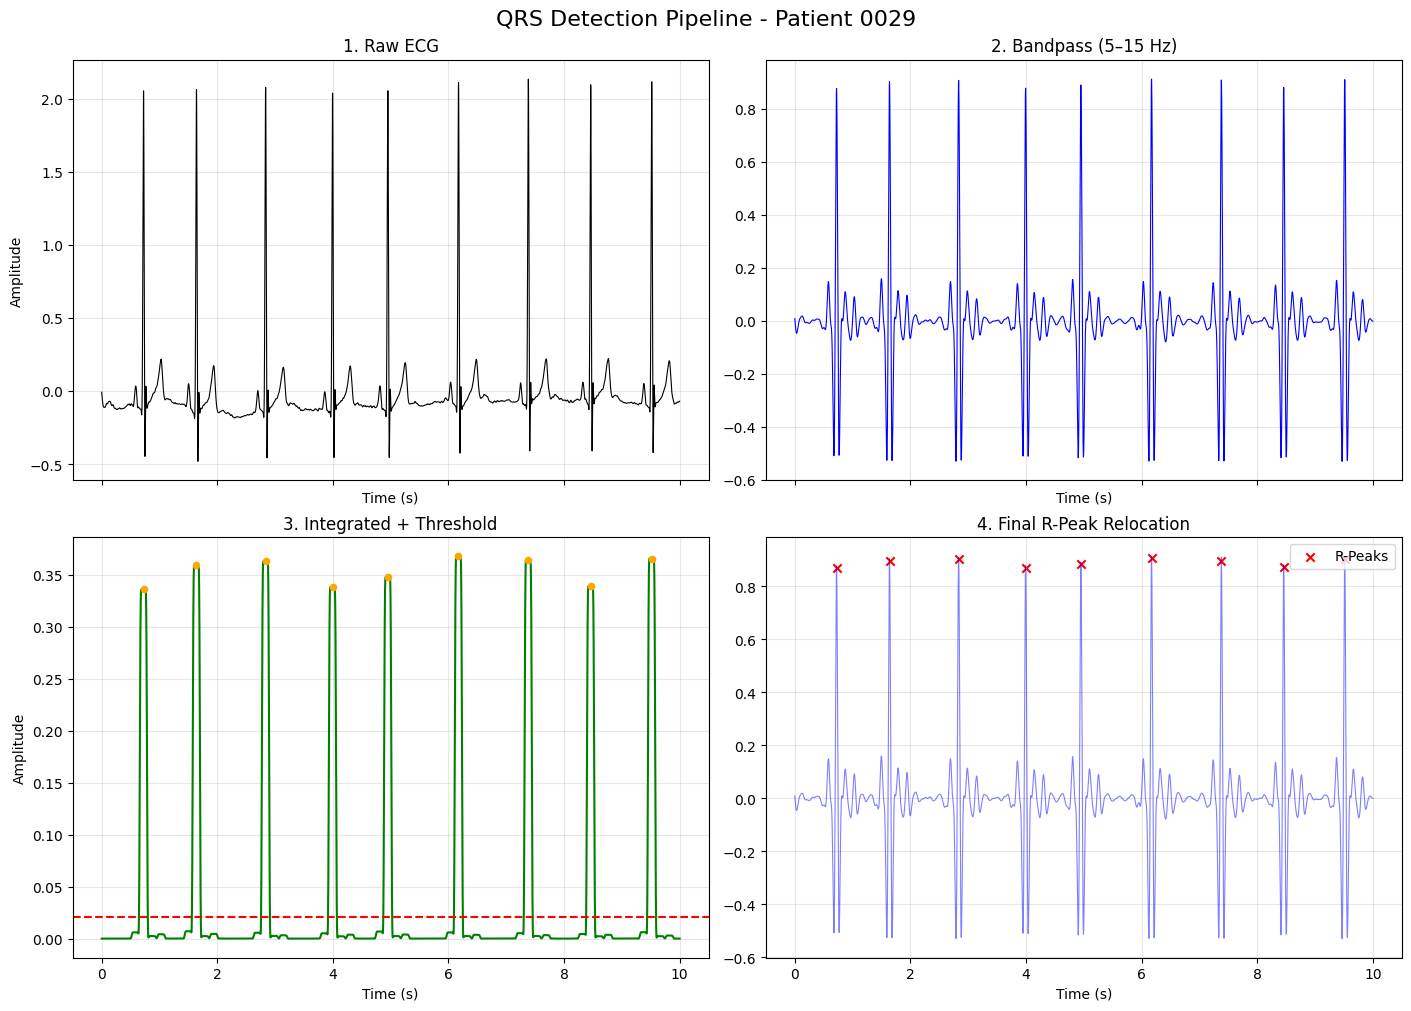

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def plot_qrs_detection(patient_id, patients_dict, fs=1000, duration_sec=10):
    # ---------------------------------------
    # 1. Extract ECG
    # ---------------------------------------
    limit = duration_sec * fs
    signal_slice = patients_dict[patient_id].p_signal[:limit]
    
    if signal_slice.ndim > 1 and signal_slice.shape[1] > 2:
        raw_ecg = signal_slice[:, 1]
    else:
        raw_ecg = signal_slice[:, 0]

    # ---------------------------------------
    # 2. Run Your QRS Detector
    # ---------------------------------------
    r_peaks, filtered, integrated = EKG_QRS_detect(raw_ecg, fs=fs)
    time = np.arange(len(raw_ecg)) / fs
    threshold = 0.5 * np.mean(integrated)

    # ---------------------------------------
    # 3. Create Subplots (2 Rows, 2 Columns)
    # ---------------------------------------
    # Change shape to (2, 2)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, constrained_layout=True)
    fig.suptitle(f"QRS Detection Pipeline - Patient {patient_id}", fontsize=16)

    # Subplot 1: Top Left - Raw ECG
    axes[0, 0].plot(time, raw_ecg, color='black', lw=0.8)
    axes[0, 0].set_title("1. Raw ECG")
    axes[0, 0].set_ylabel("Amplitude")

    # Subplot 2: Top Right - Bandpass Filtered
    axes[0, 1].plot(time, filtered, color='blue', lw=0.8)
    axes[0, 1].set_title("2. Bandpass (5–15 Hz)")

    # Subplot 3: Bottom Left - Integrated Signal + Peaks
    axes[1, 0].plot(time, integrated, color='green')
    axes[1, 0].axhline(threshold, color='red', linestyle='--', label='Threshold')
    axes[1, 0].scatter(time[r_peaks], integrated[r_peaks], color='orange', s=20, zorder=3)
    axes[1, 0].set_title("3. Integrated + Threshold")
    axes[1, 0].set_ylabel("Amplitude")

    # Subplot 4: Bottom Right - Final Detection
    axes[1, 1].plot(time, filtered, color='blue', alpha=0.5, lw=0.8)
    axes[1, 1].scatter(time[r_peaks], filtered[r_peaks], color='red', marker='x', label='R-Peaks')
    axes[1, 1].set_title("4. Final R-Peak Relocation")
    axes[1, 1].legend(loc='upper right')

    # Common formatting for the 2D array
    for ax in axes.flat:
        ax.set_xlabel("Time (s)")
        ax.grid(True, alpha=0.3)

    plt.show()

if __name__ == "__main__":
    example_patient = "0029" 
    plot_qrs_detection(
        example_patient,
        patients_dict=patients,
        fs=1000,
        duration_sec=10
    )

Discarding patients with non normal low count of beats

Mean peaks: 443.5544642857143
Std peaks: 162.29527332651253
Low threshold: 118.96391763268923
Number of abnormal patients: 8


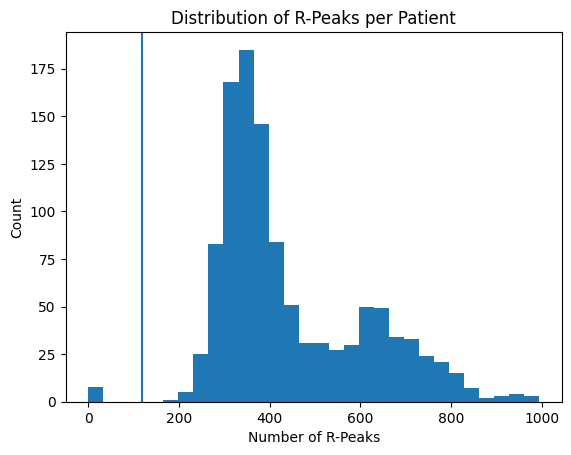


Patients with Abnormally Low R-Peaks:

Patient ID: 0332
   R-Peaks: 0
   Age Group: 4.0
   Sex: Male
----------------------------------------
Patient ID: 0359
   R-Peaks: 0
   Age Group: 2.0
   Sex: Male
----------------------------------------
Patient ID: 0405
   R-Peaks: 0
   Age Group: 4.0
   Sex: Male
----------------------------------------
Patient ID: 0500
   R-Peaks: 0
   Age Group: 3.0
   Sex: Female
----------------------------------------
Patient ID: 0902
   R-Peaks: 0
   Age Group: 2.0
   Sex: Female
----------------------------------------
Patient ID: 1001
   R-Peaks: 0
   Age Group: 2.0
   Sex: Female
----------------------------------------
Patient ID: 1011
   R-Peaks: 0
   Age Group: 3.0
   Sex: Male
----------------------------------------
Patient ID: 1119
   R-Peaks: 0
   Age Group: 2.0
   Sex: Male
----------------------------------------
Cleaned file saved as r_indices.csv


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Use your existing dataframe
df = results_df.copy()

# ----------------------------------------
# 1. Define low-peak threshold
# ----------------------------------------
mean_peaks = df["Num_R_Peaks"].mean()
std_peaks = df["Num_R_Peaks"].std()

low_threshold = mean_peaks - 2 * std_peaks

low_peak_patients = df[df["Num_R_Peaks"] < low_threshold]

print("Mean peaks:", mean_peaks)
print("Std peaks:", std_peaks)
print("Low threshold:", low_threshold)
print("Number of abnormal patients:", len(low_peak_patients))

# ----------------------------------------
# 2. Plot distribution
# ----------------------------------------
plt.figure()
plt.hist(df["Num_R_Peaks"], bins=30)
plt.axvline(low_threshold)
plt.title("Distribution of R-Peaks per Patient")
plt.xlabel("Number of R-Peaks")
plt.ylabel("Count")
plt.show()

# ----------------------------------------
# 3. Plot one abnormal example
# ----------------------------------------
if len(low_peak_patients) > 0:

    print("\nPatients with Abnormally Low R-Peaks:\n")

    for _, row in low_peak_patients.iterrows():

        pid = row["Patient_ID"]
        num_peaks = row["Num_R_Peaks"]

        if pid in patients:
            p_record = patients[pid]
            p_info = p_record.metadata

            age_group = p_info.get("Age_group", "Unknown")
            sex = "Male" if p_info.get("Sex", None) == 0.0 else "Female"

            print(f"Patient ID: {pid}")
            print(f"   R-Peaks: {num_peaks}")
            print(f"   Age Group: {age_group}")
            print(f"   Sex: {sex}")
            print("-" * 40)


# ----------------------------------------
# 4. Remove them and save cleaned CSV
# ----------------------------------------
clean_df = df[df["Num_R_Peaks"] >= low_threshold]

#clean_df.to_csv("r_indices.csv", index=False)

print("Cleaned file saved as r_indices.csv")


Cleaned Patients: 1112
Total Males: 424
Total Females: 688

Age Group Distribution:
2.0: 418
7.0: 50
4.0: 103
3.0: 227
1.0: 46
9.0: 18
8.0: 50
Unknown: 25
12.0: 13
5.0: 43
10.0: 24
11.0: 19
6.0: 50
13.0: 7
15.0: 7
14.0: 12


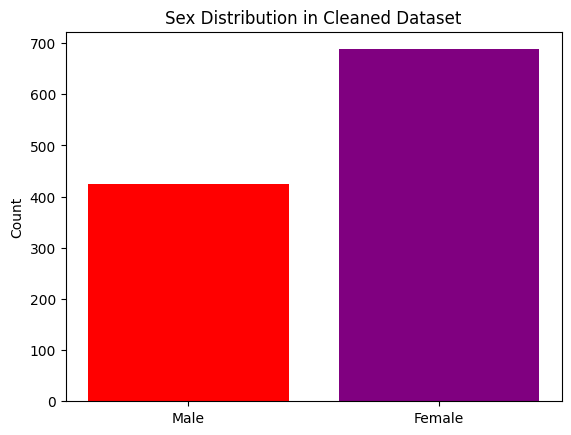

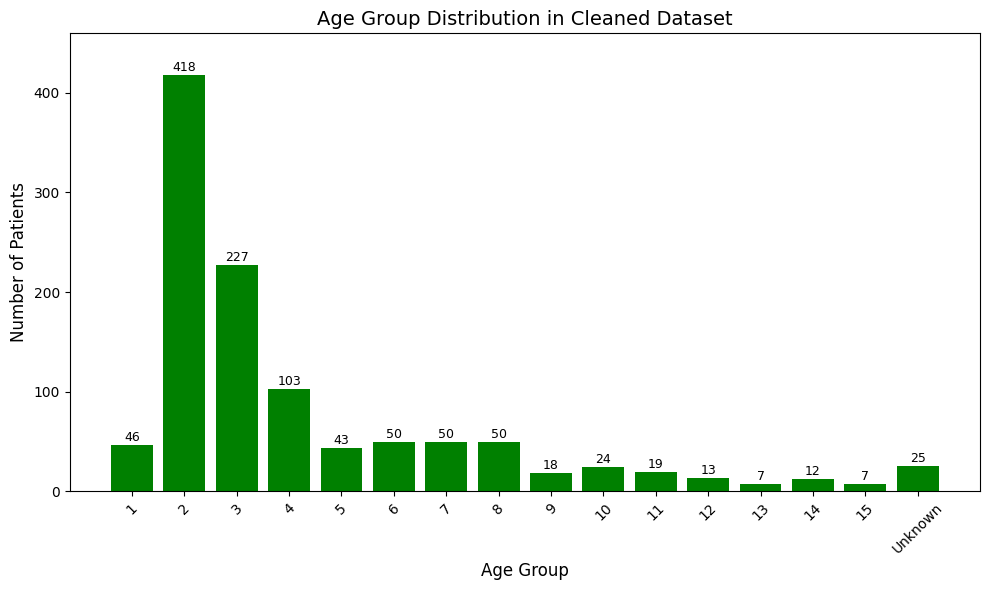

In [19]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

# 1️ Load cleaned CSV
df_clean = pd.read_csv(r"C:\Users\34673\Desktop\UNI\UNI 2025\TFG\r_indices.csv")

# 3️ Loop through cleaned patients
male_count = 0
female_count = 0
age_counter = Counter()

for pid in df_clean["Patient_ID"]:
    pid = str(pid).strip().zfill(4)  # ensure it matches patients dict keys

    if pid in patients:
        metadata = patients[pid].metadata

        if metadata.get("Sex") == 0.0:
            male_count += 1
        else:
            female_count += 1

        from collections import Counter


    
   
        
        age_group = metadata.get("Age_group", "Unknown")  # fallback

        # Handle None / np.nan
        if age_group is None or (isinstance(age_group, float) and np.isnan(age_group)):
            age_group = "Unknown"

        age_counter[age_group] += 1

    else:
        print(f"Warning: Patient {pid} not found in patients dict")


# 4️ Print Results

print("Cleaned Patients:", len(df_clean))
print("Total Males:", male_count)
print("Total Females:", female_count)

print("\nAge Group Distribution:")
for age_group, count in age_counter.items():
    print(f"{age_group}: {count}")

# 5️ Optional: Plot

# Sex distribution
plt.figure()
plt.bar(["Male", "Female"], [male_count, female_count], color=['red', 'purple'])
plt.title("Sex Distribution in Cleaned Dataset")
plt.ylabel("Count")
plt.show()

# Age group distribution
import matplotlib.pyplot as plt

# ------------------------------
# 1️⃣ Clean and separate keys
# ------------------------------
numeric_age = []
numeric_counts = []

unknown_count = 0

for k, count in age_counter.items():
    if k == "Unknown" or k is None or (isinstance(k, float) and np.isnan(k)):
        unknown_count += int(count)
    else:
        numeric_age.append(int(float(k)))  # convert to int
        numeric_counts.append(int(count))

# Sort numeric age groups
sorted_pairs = sorted(zip(numeric_age, numeric_counts), key=lambda x: x[0])
sorted_age, sorted_counts = zip(*sorted_pairs) if sorted_pairs else ([], [])

# Add "Unknown" at the end if exists
if unknown_count > 0:
    sorted_age = list(sorted_age) + ["Unknown"]
    sorted_counts = list(sorted_counts) + [unknown_count]

# Convert all x-values to strings for plotting
x_labels = [str(a) for a in sorted_age]

# ------------------------------
# 2️⃣ Plot
# ------------------------------
plt.figure(figsize=(10, 6))
bars = plt.bar(x_labels, sorted_counts, color='green')

# Add counts on top of bars
for bar, count in zip(bars, sorted_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(count),
             ha='center', va='bottom', fontsize=9)

plt.title("Age Group Distribution in Cleaned Dataset", fontsize=14)
plt.ylabel("Number of Patients", fontsize=12)
plt.xlabel("Age Group", fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, max(sorted_counts)*1.1)
plt.tight_layout()
plt.show()



**3 Obtaining RR intervals** (https://github.com/claudiavmbrito/RPeakDetection/blob/master/biospy_rpeak.py)

In [20]:
import pandas as pd
import numpy as np

# Load cleaned CSV with R-peaks
df_clean = pd.read_csv("r_indices.csv")

# Sampling frequency
fs = 1000

# Prepare list to store all patient data
all_patients_data = []

for idx, row in df_clean.iterrows():
    pid = str(row["Patient_ID"]).strip().zfill(4)

    # Load R-peak indices
    r_peaks = row["R_peak_indices"]
    if isinstance(r_peaks, str):
        r_peaks = eval(r_peaks)  # convert string to list
    r_peaks = np.array(r_peaks)

    # Compute RR intervals in ms
    rr_intervals = np.diff(r_peaks) / fs * 1000  # milliseconds

    # Compute heart rate in bpm
    hr = 60 * fs / np.diff(r_peaks)

    # Append to list
    all_patients_data.append({
        "Patient_ID": pid,
        "Num_R_Peaks": len(r_peaks),
        "R_peak_indices": r_peaks.tolist(),
        "RR_intervals_ms": rr_intervals.tolist(),
        "Heart_rate_bpm": hr.tolist()
    })

# Convert to DataFrame
df_rr_all = pd.DataFrame(all_patients_data)

# Save to CSV
df_rr_all.to_csv("rr_hr_all_patients.csv", index=False)

print("CSV saved as rr_hr_all_patients.csv")


CSV saved as rr_hr_all_patients.csv


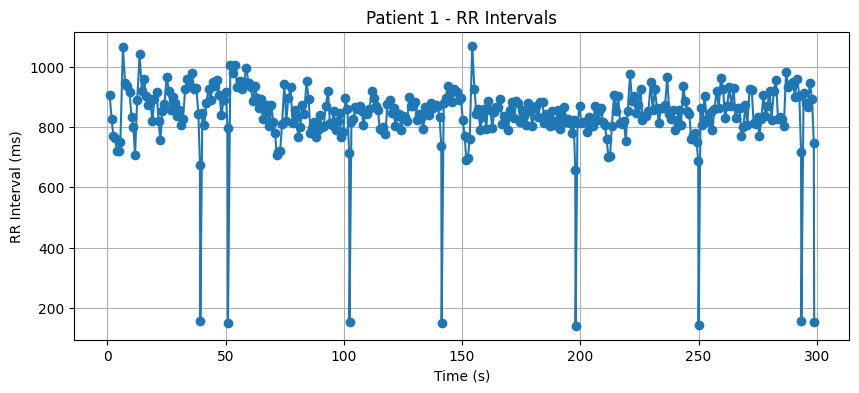

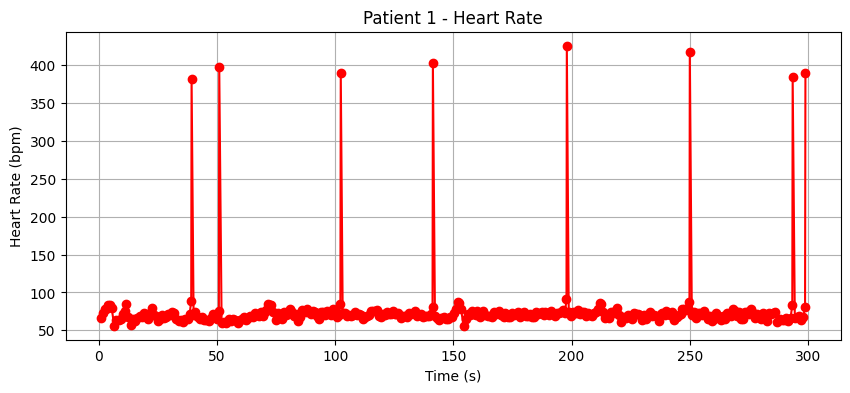

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast  # safer than eval


df_rr_all = pd.read_csv("rr_hr_all_patients.csv")


example_patient = df_rr_all.iloc[0]  # first patient
pid = example_patient["Patient_ID"]

rr_intervals = ast.literal_eval(example_patient["RR_intervals_ms"])
hr = ast.literal_eval(example_patient["Heart_rate_bpm"])

# Compute time axis for RR and HR (midpoint between R-peaks)
# We don’t have R_peak timestamps directly, so approximate as cumulative sum of RR intervals
time_rr = np.cumsum(rr_intervals) / 1000  # convert ms to seconds


plt.figure(figsize=(10, 4))
plt.plot(time_rr, rr_intervals, marker='o', linestyle='-')
plt.title(f"Patient {pid} - RR Intervals")
plt.xlabel("Time (s)")
plt.ylabel("RR Interval (ms)")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_rr, hr, marker='o', linestyle='-', color='red')
plt.title(f"Patient {pid} - Heart Rate")
plt.xlabel("Time (s)")
plt.ylabel("Heart Rate (bpm)")
plt.grid(True)
plt.show()
